<a href="https://www.kaggle.com/code/omborse771924/food-delivery-orders-eta-logistics-81-accuracy?scriptVersionId=343697774" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/razanihababdellatif/food-delivery-orders-and-eta-logistics-dataset/food_delivery_orders_dataset.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/food-delivery-orders-and-eta-logistics-dataset/food_delivery_orders_dataset.csv')

In [3]:
df.head()

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9


In [4]:
df.tail()

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
49995,ORD_049996,CUS_00280,RES_0130,DRV_0112,2025-10-25 12:16:00,2025-10-25,12,Saturday,1,City_B,...,Medium,34,5.0,11,19,21.0,0.0,Completed,NaN,4.4
49996,ORD_049997,CUS_00893,RES_0028,DRV_0036,2025-10-05 19:48:00,2025-10-05,19,Sunday,1,City_B,...,High,49,5.0,9,28,29.0,0.0,Completed,NaN,4.8
49997,ORD_049998,CUS_01618,RES_0001,DRV_0071,2025-10-08 12:18:00,2025-10-08,12,Wednesday,0,City_A,...,High,54,4.1,11,18,16.0,0.0,Completed,NaN,4.7
49998,ORD_049999,CUS_00025,RES_0057,DRV_0103,2025-10-20 17:39:00,2025-10-20,17,Monday,0,City_A,...,High,33,4.0,20,17,27.0,1.0,Completed,NaN,3.8
49999,ORD_050000,CUS_00038,RES_0139,DRV_0131,2025-10-13 17:36:00,2025-10-13,17,Monday,0,City_A,...,Low,44,4.7,12,30,40.0,1.0,Completed,NaN,4.5


In [5]:
df.info

<bound method DataFrame.info of          order_id customer_id restaurant_id driver_id      order_timestamp  \
0      ORD_000001   CUS_00001      RES_0008  DRV_0075  2025-10-05 15:54:00   
1      ORD_000002   CUS_00013      RES_0024  DRV_0131  2025-10-01 20:00:00   
2      ORD_000003   CUS_00049      RES_0013  DRV_0087  2025-10-07 18:24:00   
3      ORD_000004   CUS_00007      RES_0001  DRV_0177  2025-10-30 16:54:00   
4      ORD_000005   CUS_00325      RES_0029  DRV_0114  2025-10-15 18:34:00   
...           ...         ...           ...       ...                  ...   
49995  ORD_049996   CUS_00280      RES_0130  DRV_0112  2025-10-25 12:16:00   
49996  ORD_049997   CUS_00893      RES_0028  DRV_0036  2025-10-05 19:48:00   
49997  ORD_049998   CUS_01618      RES_0001  DRV_0071  2025-10-08 12:18:00   
49998  ORD_049999   CUS_00025      RES_0057  DRV_0103  2025-10-20 17:39:00   
49999  ORD_050000   CUS_00038      RES_0139  DRV_0131  2025-10-13 17:36:00   

       order_date  order_hour d

In [6]:
df.describe

<bound method NDFrame.describe of          order_id customer_id restaurant_id driver_id      order_timestamp  \
0      ORD_000001   CUS_00001      RES_0008  DRV_0075  2025-10-05 15:54:00   
1      ORD_000002   CUS_00013      RES_0024  DRV_0131  2025-10-01 20:00:00   
2      ORD_000003   CUS_00049      RES_0013  DRV_0087  2025-10-07 18:24:00   
3      ORD_000004   CUS_00007      RES_0001  DRV_0177  2025-10-30 16:54:00   
4      ORD_000005   CUS_00325      RES_0029  DRV_0114  2025-10-15 18:34:00   
...           ...         ...           ...       ...                  ...   
49995  ORD_049996   CUS_00280      RES_0130  DRV_0112  2025-10-25 12:16:00   
49996  ORD_049997   CUS_00893      RES_0028  DRV_0036  2025-10-05 19:48:00   
49997  ORD_049998   CUS_01618      RES_0001  DRV_0071  2025-10-08 12:18:00   
49998  ORD_049999   CUS_00025      RES_0057  DRV_0103  2025-10-20 17:39:00   
49999  ORD_050000   CUS_00038      RES_0139  DRV_0131  2025-10-13 17:36:00   

       order_date  order_hour

In [7]:
df.info


<bound method DataFrame.info of          order_id customer_id restaurant_id driver_id      order_timestamp  \
0      ORD_000001   CUS_00001      RES_0008  DRV_0075  2025-10-05 15:54:00   
1      ORD_000002   CUS_00013      RES_0024  DRV_0131  2025-10-01 20:00:00   
2      ORD_000003   CUS_00049      RES_0013  DRV_0087  2025-10-07 18:24:00   
3      ORD_000004   CUS_00007      RES_0001  DRV_0177  2025-10-30 16:54:00   
4      ORD_000005   CUS_00325      RES_0029  DRV_0114  2025-10-15 18:34:00   
...           ...         ...           ...       ...                  ...   
49995  ORD_049996   CUS_00280      RES_0130  DRV_0112  2025-10-25 12:16:00   
49996  ORD_049997   CUS_00893      RES_0028  DRV_0036  2025-10-05 19:48:00   
49997  ORD_049998   CUS_01618      RES_0001  DRV_0071  2025-10-08 12:18:00   
49998  ORD_049999   CUS_00025      RES_0057  DRV_0103  2025-10-20 17:39:00   
49999  ORD_050000   CUS_00038      RES_0139  DRV_0131  2025-10-13 17:36:00   

       order_date  order_hour d

In [8]:
df.isnull()

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
49996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
49997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
49998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [9]:
df.isnull().sum()

order_id                                   0
customer_id                                0
restaurant_id                              0
driver_id                                  0
order_timestamp                            0
order_date                                 0
order_hour                                 0
day_of_week                                0
is_weekend                                 0
city                                       0
delivery_area                              0
customer_age                               0
customer_type                              0
restaurant_type                            0
restaurant_primary_category                0
restaurant_rating                          0
items_count                                0
subtotal                                   0
discount_percent                           0
tax_amount                                 0
service_fee                                0
delivery_fee                               0
order_tota

In [10]:
# ==========================================================
# HANDLE NULL VALUES - FOOD DELIVERY DATASET
# ==========================================================

import pandas as pd
import numpy as np

# Make a copy
data = df.copy()

# ==========================================================
# 1. CHECK INITIAL NULL VALUES
# ==========================================================

print("=" * 70)
print("INITIAL NULL VALUES")
print("=" * 70)

initial_nulls = data.isnull().sum()

print(
    initial_nulls[initial_nulls > 0]
    .sort_values(ascending=False)
)

# ==========================================================
# 2. HANDLE NUMERICAL NULL VALUES
# ==========================================================

numeric_columns = [
    "tip_amount",
    "actual_delivery_time_minutes",
    "customer_rating"
]

# Keep only columns that exist
numeric_columns = [
    col for col in numeric_columns
    if col in data.columns
]

for col in numeric_columns:

    if data[col].isnull().sum() > 0:

        median_value = data[col].median()

        data[col] = data[col].fillna(
            median_value
        )

        print(
            f"{col}: filled with median = "
            f"{median_value:.2f}"
        )

# ==========================================================
# 3. HANDLE LATE DELIVERY
# ==========================================================

if "late_delivery" in data.columns:

    if data["late_delivery"].isnull().sum() > 0:

        # If late_delivery is numeric/binary
        if pd.api.types.is_numeric_dtype(
            data["late_delivery"]
        ):

            mode_value = data[
                "late_delivery"
            ].mode()[0]

            data["late_delivery"] = (
                data["late_delivery"]
                .fillna(mode_value)
            )

            print(
                "late_delivery: filled with mode =",
                mode_value
            )

        else:

            data["late_delivery"] = (
                data["late_delivery"]
                .fillna("Unknown")
            )

            print(
                "late_delivery: filled with 'Unknown'"
            )

# ==========================================================
# 4. HANDLE CANCELLATION REASON
# ==========================================================

if "cancellation_reason" in data.columns:

    missing_count = (
        data["cancellation_reason"]
        .isnull()
        .sum()
    )

    if missing_count > 0:

        # A missing cancellation reason generally means
        # the order was not cancelled.
        data["cancellation_reason"] = (
            data["cancellation_reason"]
            .fillna("Not Cancelled")
        )

        print(
            "cancellation_reason: filled with "
            "'Not Cancelled'"
        )

# ==========================================================
# 5. FINAL NULL CHECK
# ==========================================================

print("\n" + "=" * 70)
print("FINAL NULL VALUES")
print("=" * 70)

final_nulls = data.isnull().sum()

remaining_nulls = final_nulls[
    final_nulls > 0
]

if len(remaining_nulls) == 0:

    print("No missing values remaining.")

else:

    print(remaining_nulls)

# ==========================================================
# 6. TOTAL NULL VALUES
# ==========================================================

total_nulls = (
    data.isnull().sum().sum()
)

print("\nTotal remaining null values:")
print(total_nulls)

# ==========================================================
# 7. DATASET INFORMATION
# ==========================================================

print("\n" + "=" * 70)
print("CLEANED DATASET")
print("=" * 70)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

# ==========================================================
# 8. UPDATE df
# ==========================================================

df = data.copy()

print("\nNull value handling completed successfully!")

INITIAL NULL VALUES
cancellation_reason             49132
tip_amount                        868
actual_delivery_time_minutes      868
late_delivery                     868
customer_rating                   868
dtype: int64
tip_amount: filled with median = 0.00
actual_delivery_time_minutes: filled with median = 33.00
customer_rating: filled with median = 4.40
late_delivery: filled with mode = 0.0
cancellation_reason: filled with 'Not Cancelled'

FINAL NULL VALUES
No missing values remaining.

Total remaining null values:
0

CLEANED DATASET
Rows    : 50000
Columns : 37

Null value handling completed successfully!


In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'driver_id',
       'order_timestamp', 'order_date', 'order_hour', 'day_of_week',
       'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type',
       'restaurant_type', 'restaurant_primary_category', 'restaurant_rating',
       'items_count', 'subtotal', 'discount_percent', 'tax_amount',
       'service_fee', 'delivery_fee', 'order_total', 'payment_method',
       'tip_amount', 'distance_km', 'weather', 'traffic_level',
       'delivery_partner_experience_months', 'delivery_partner_rating',
       'restaurant_preparation_time_minutes',
       'estimated_delivery_time_minutes', 'actual_delivery_time_minutes',
       'late_delivery', 'order_status', 'cancellation_reason',
       'customer_rating'],
      dtype='object')

## EDA

Shape: (50000, 37)

Columns:
['order_id', 'customer_id', 'restaurant_id', 'driver_id', 'order_timestamp', 'order_date', 'order_hour', 'day_of_week', 'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type', 'restaurant_type', 'restaurant_primary_category', 'restaurant_rating', 'items_count', 'subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee', 'order_total', 'payment_method', 'tip_amount', 'distance_km', 'weather', 'traffic_level', 'delivery_partner_experience_months', 'delivery_partner_rating', 'restaurant_preparation_time_minutes', 'estimated_delivery_time_minutes', 'actual_delivery_time_minutes', 'late_delivery', 'order_status', 'cancellation_reason', 'customer_rating']

Numerical Columns:
['order_hour', 'is_weekend', 'customer_age', 'restaurant_rating', 'items_count', 'subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee', 'order_total', 'tip_amount', 'distance_km', 'delivery_partner_experience_months', 'delivery_partner_ra

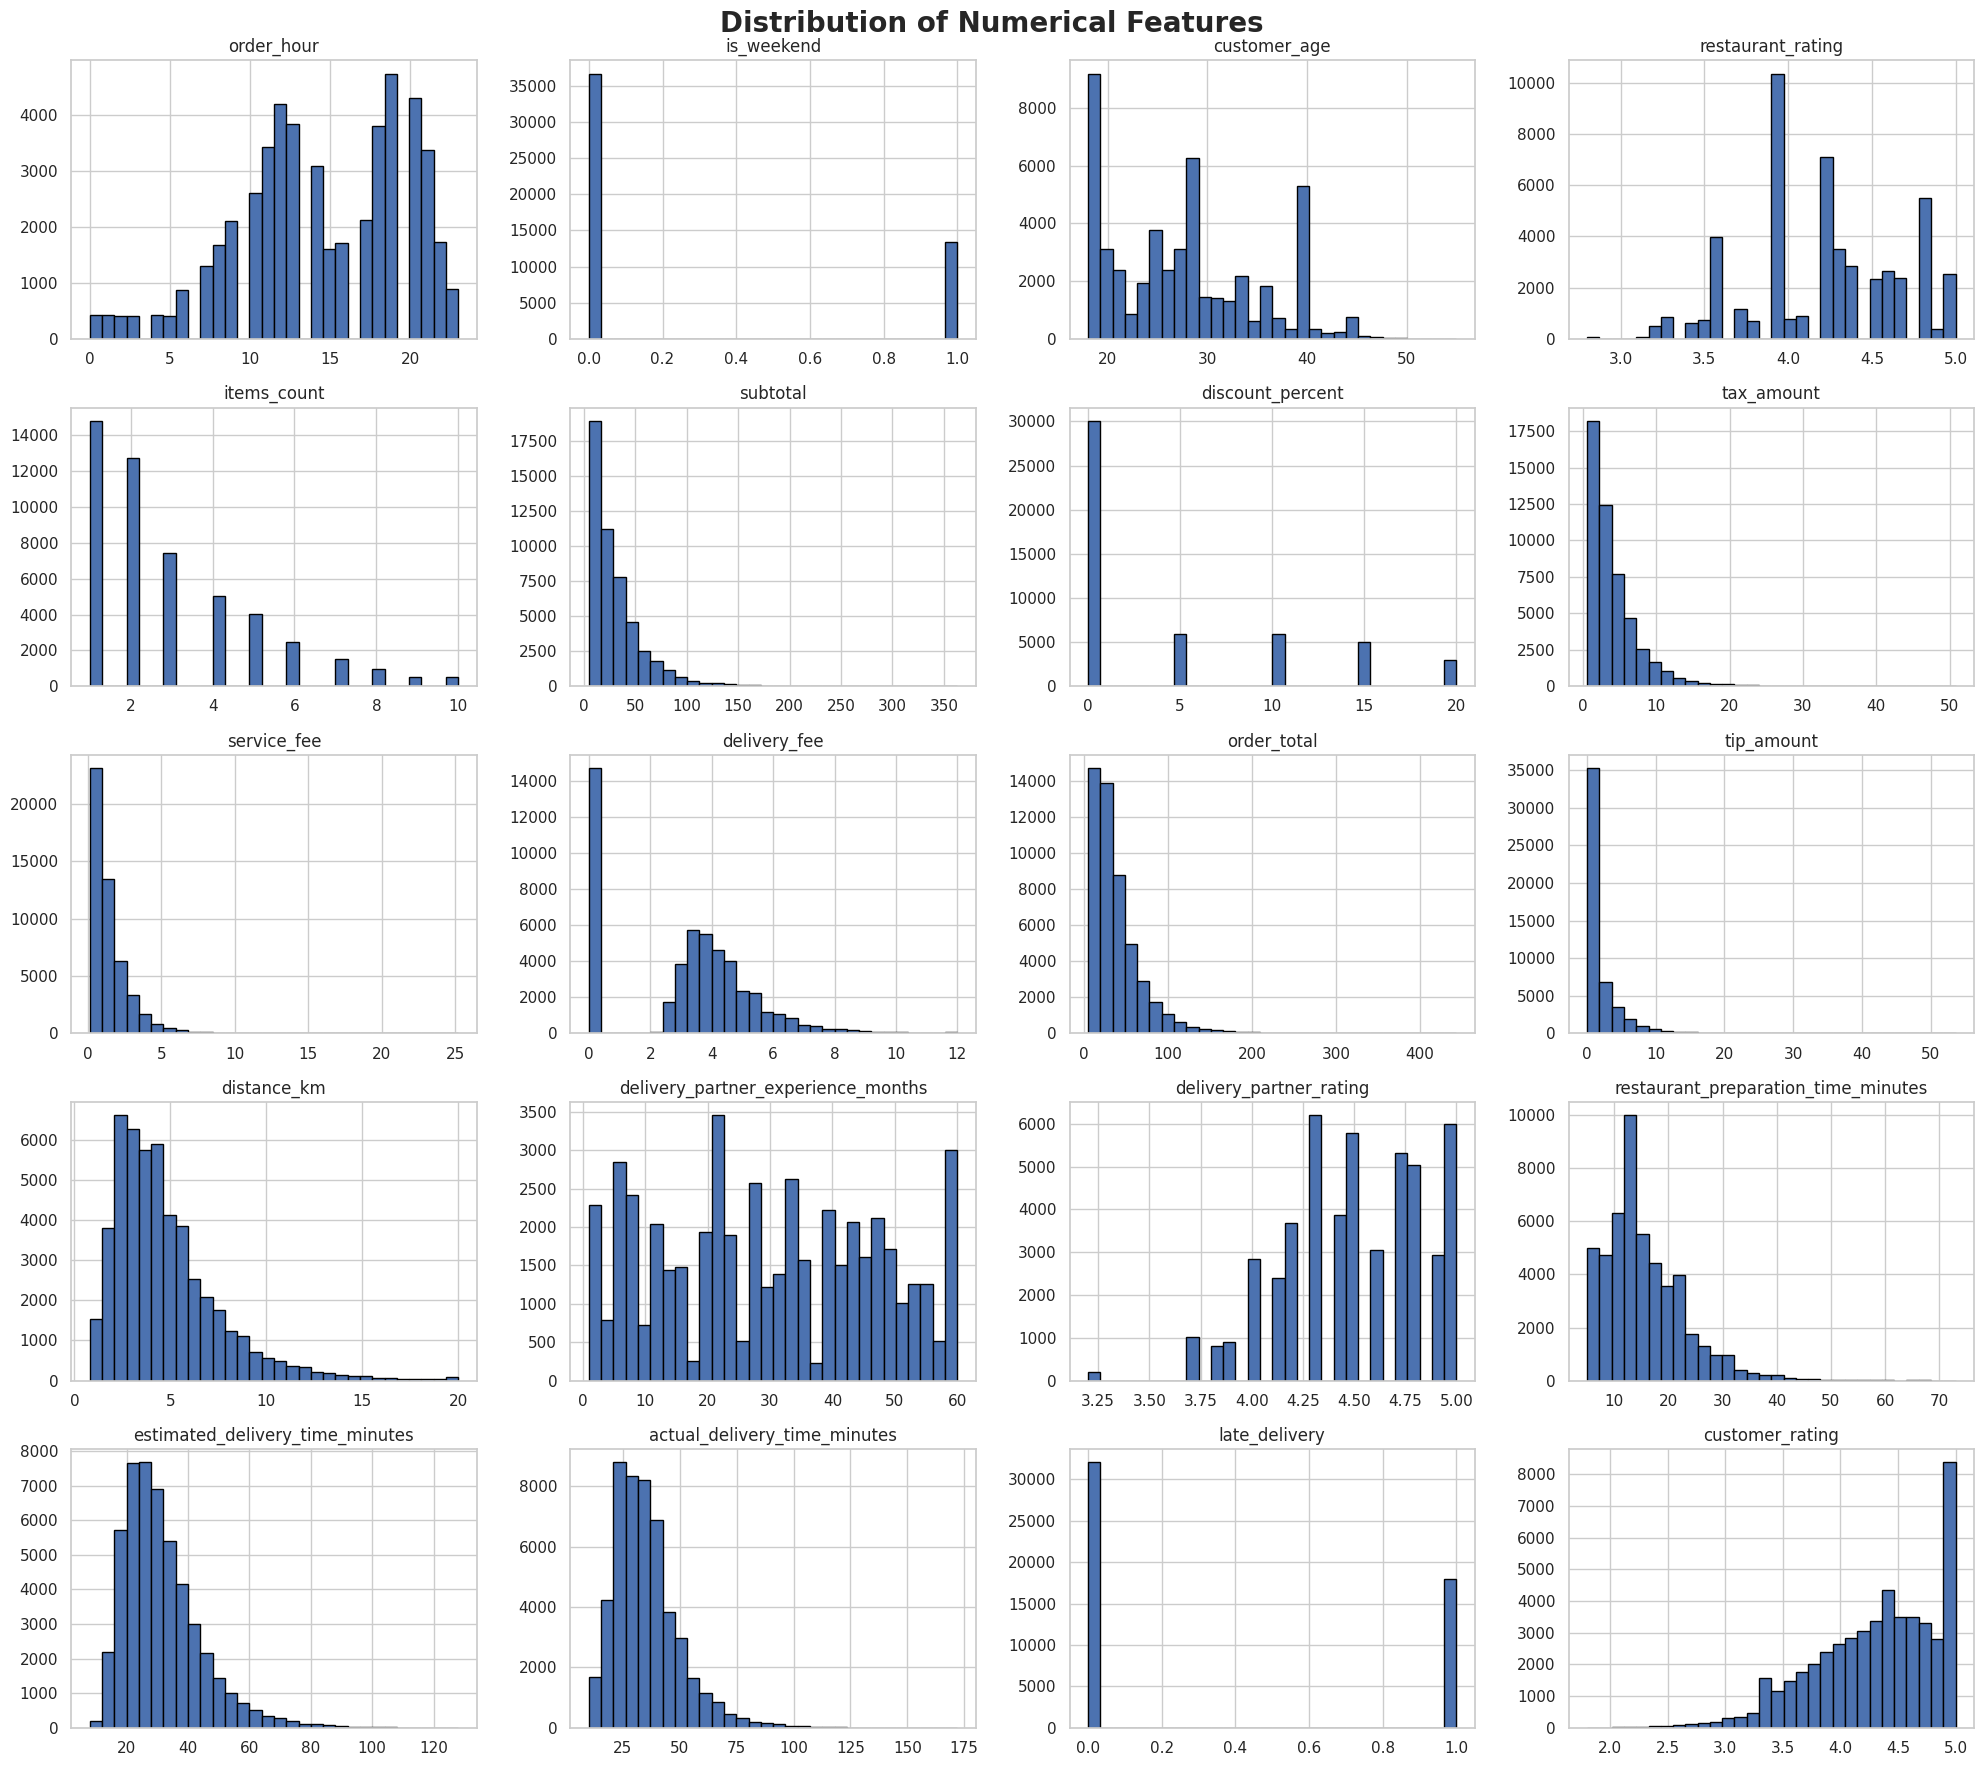

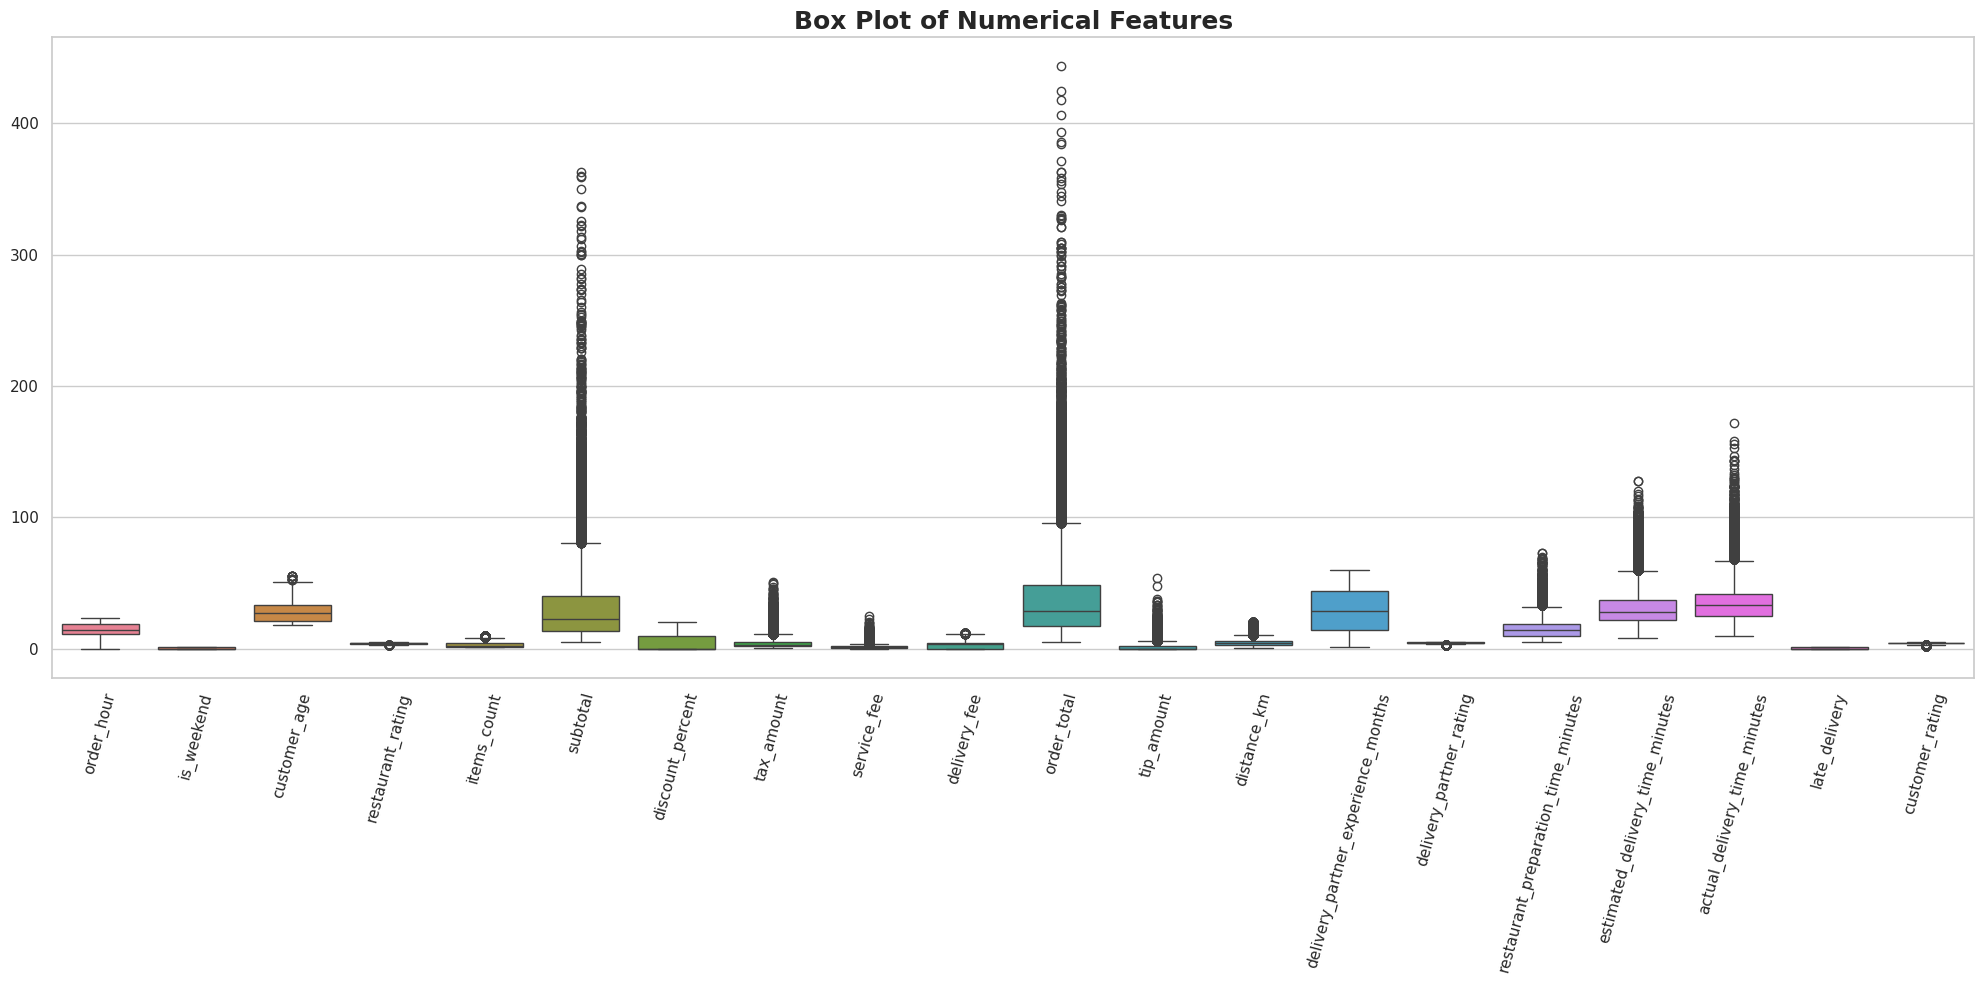

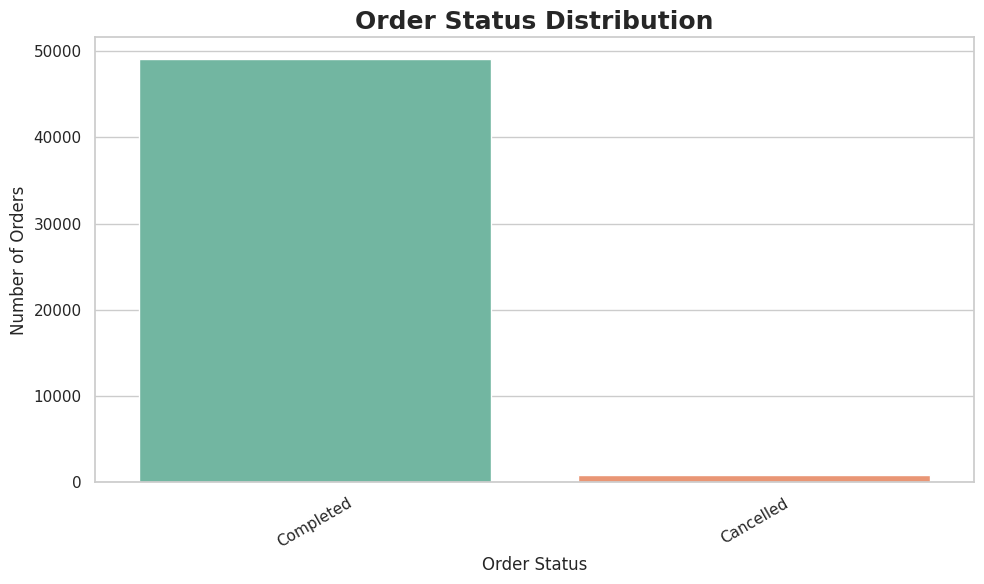

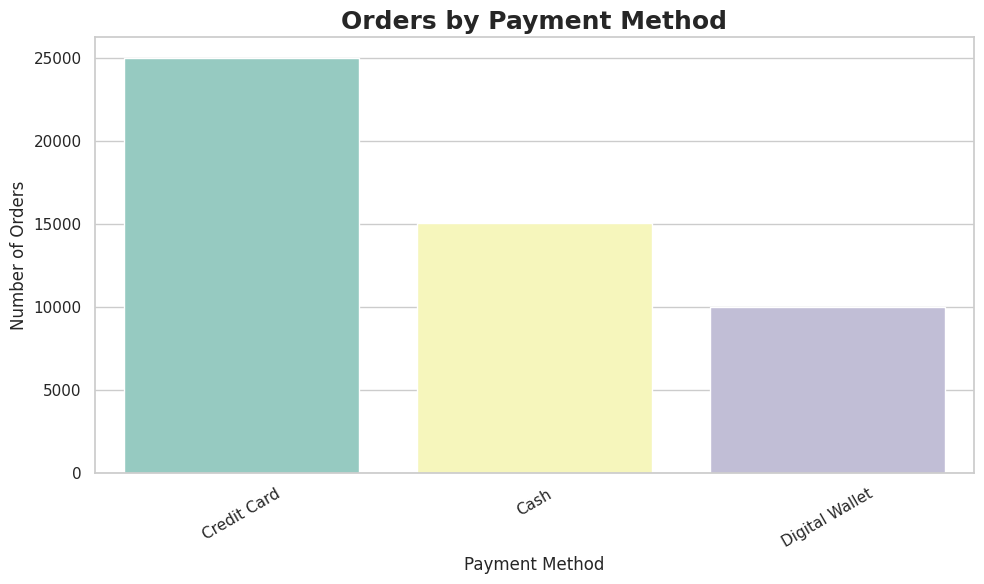

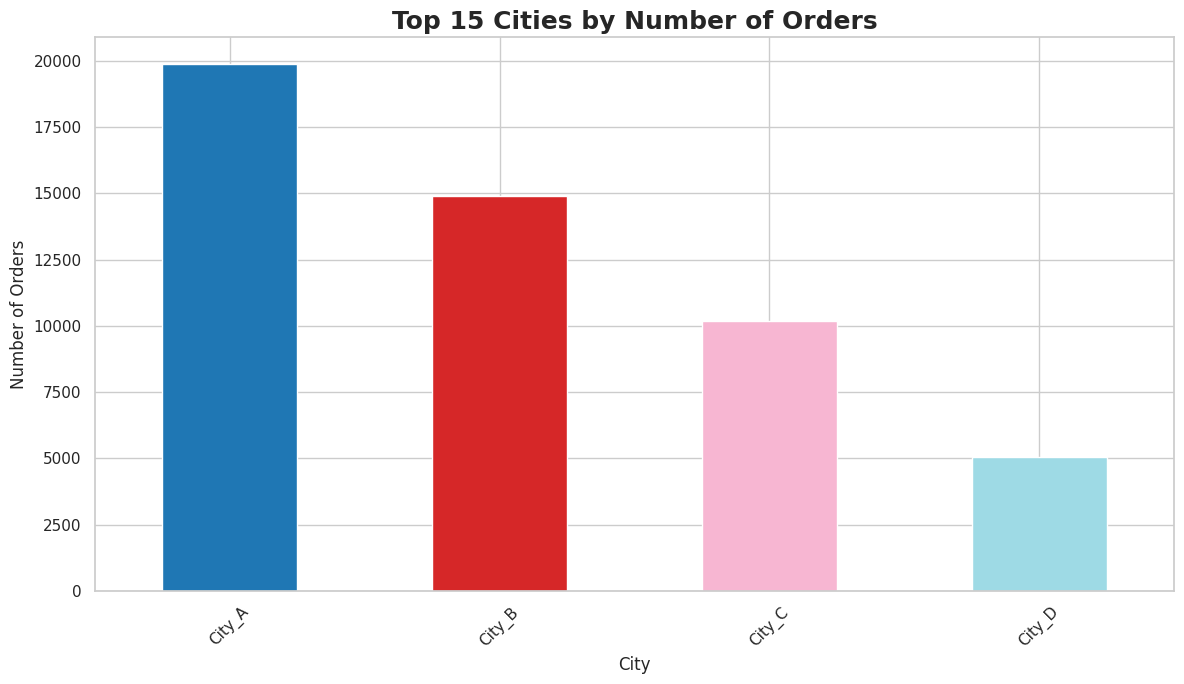

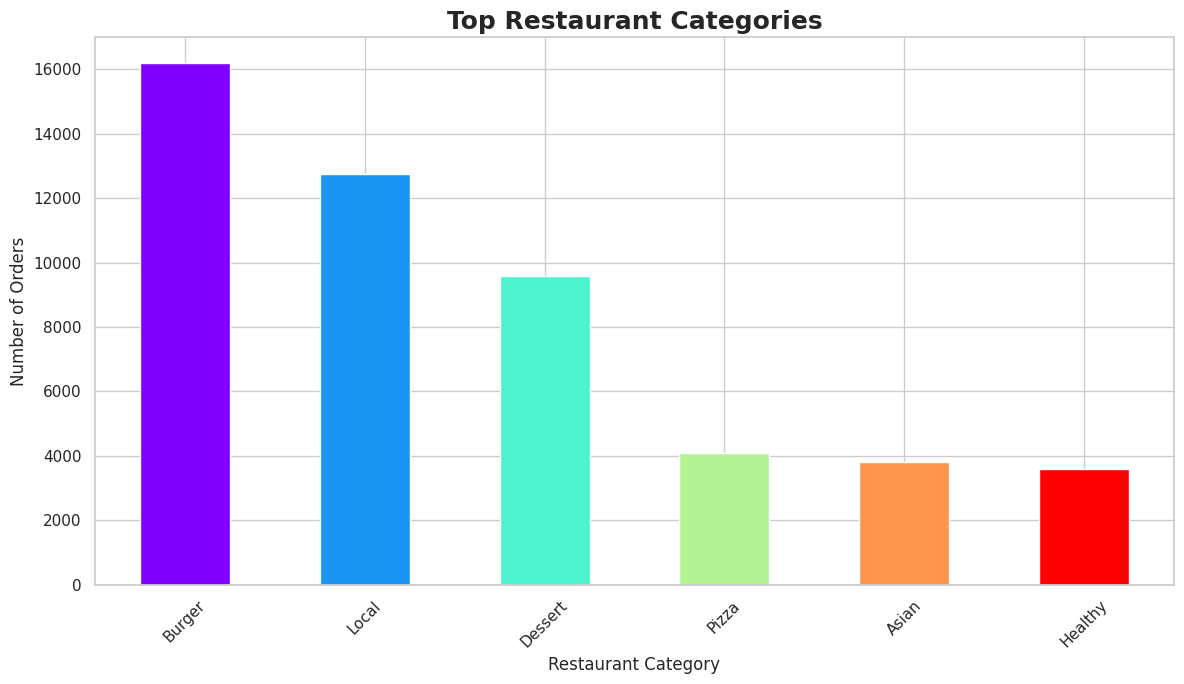

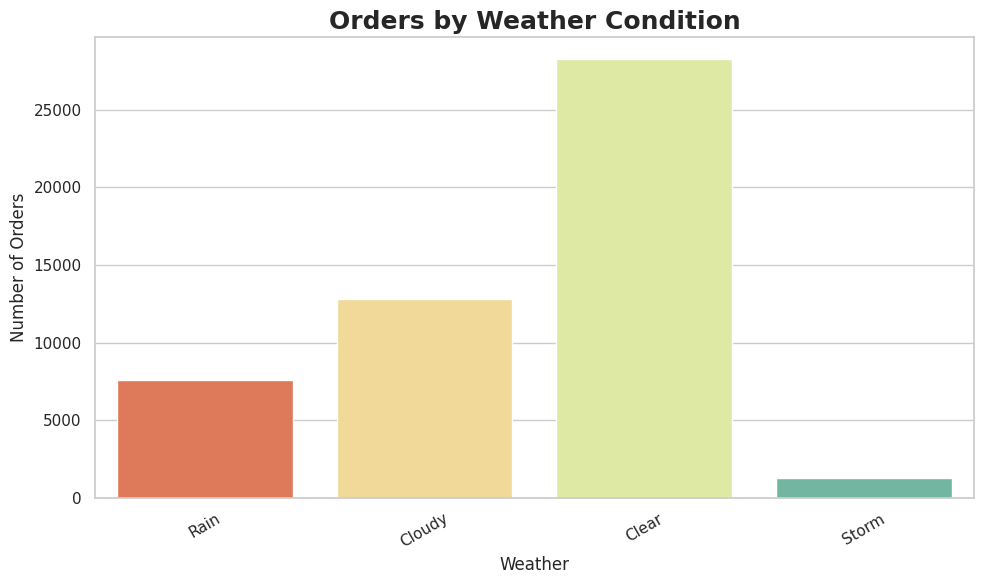

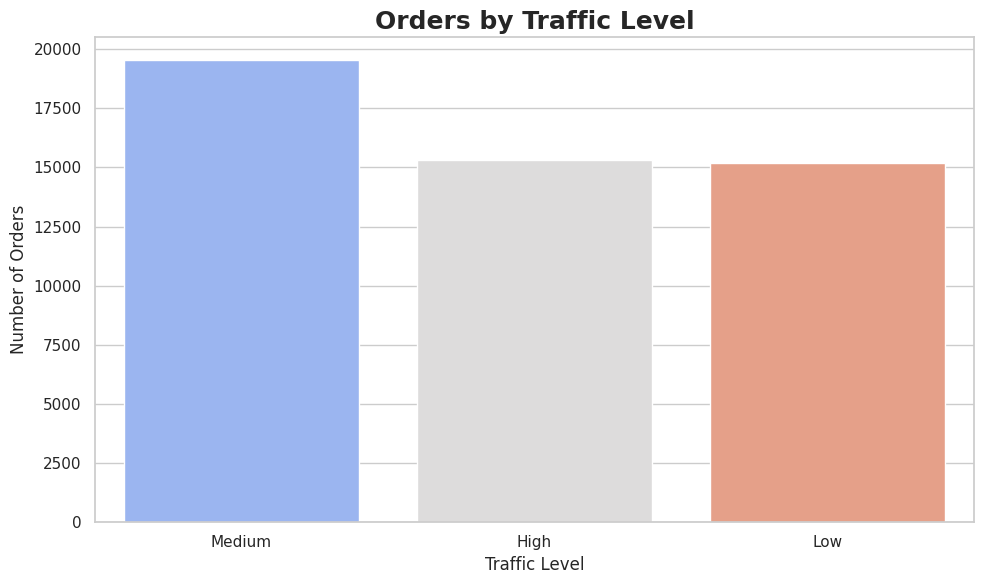

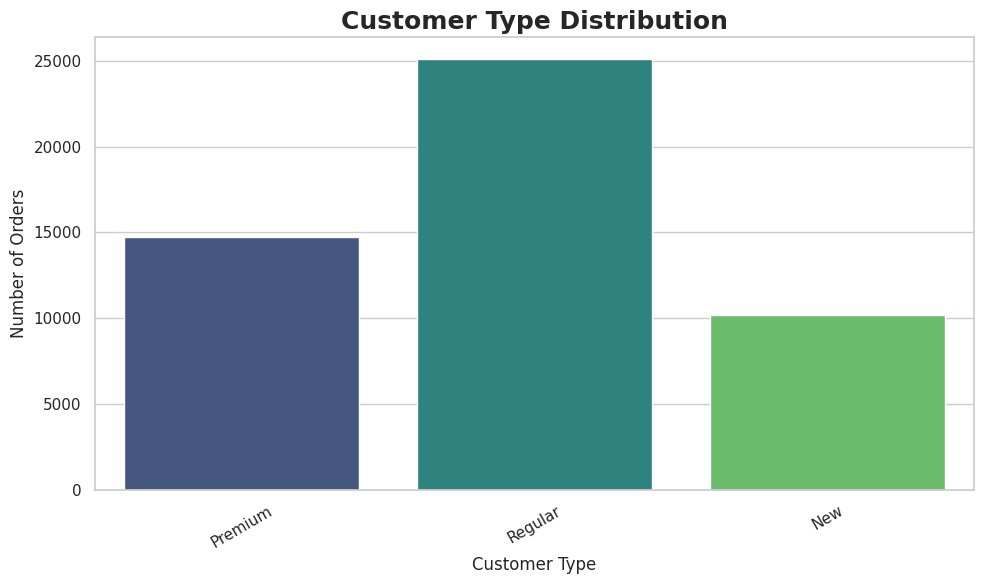

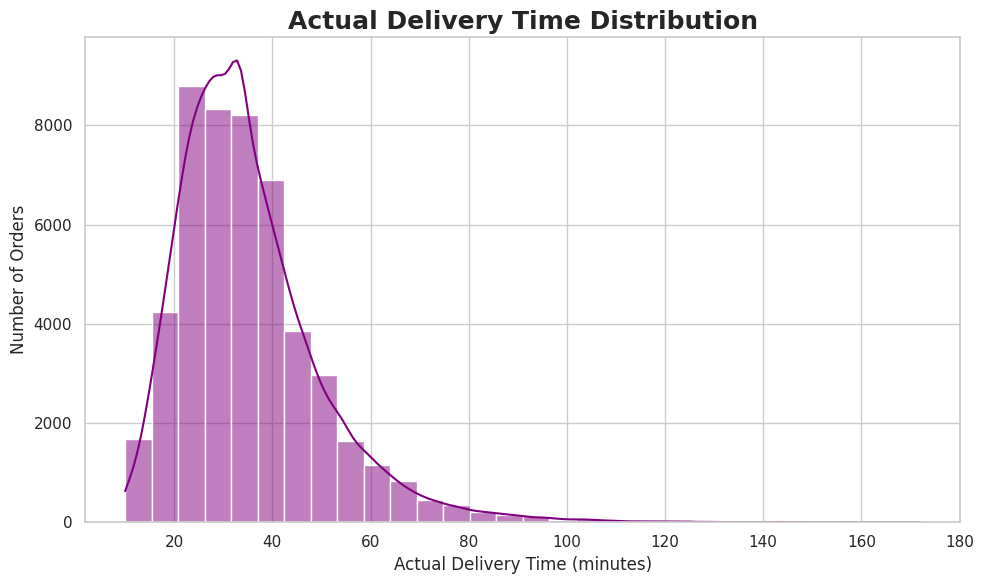

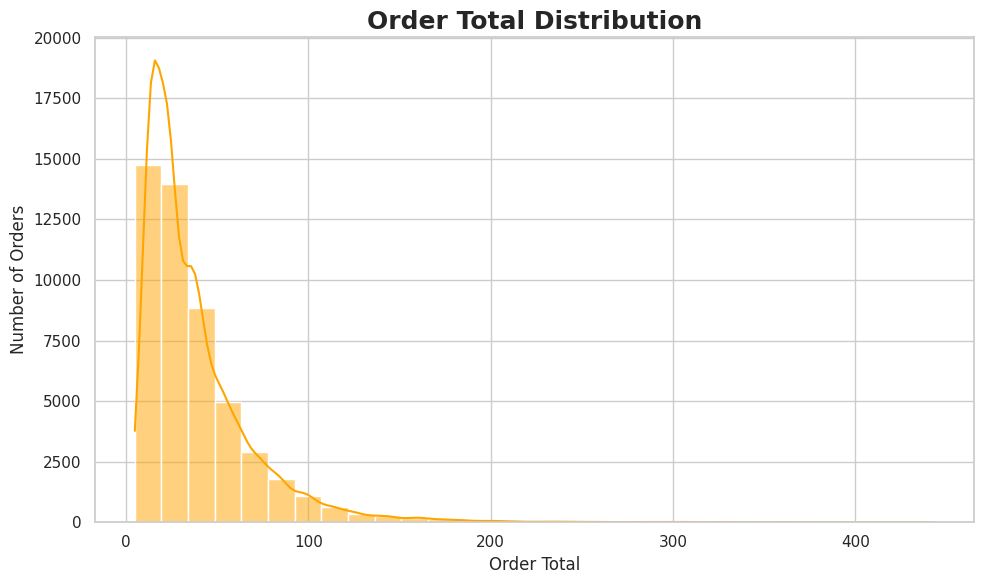

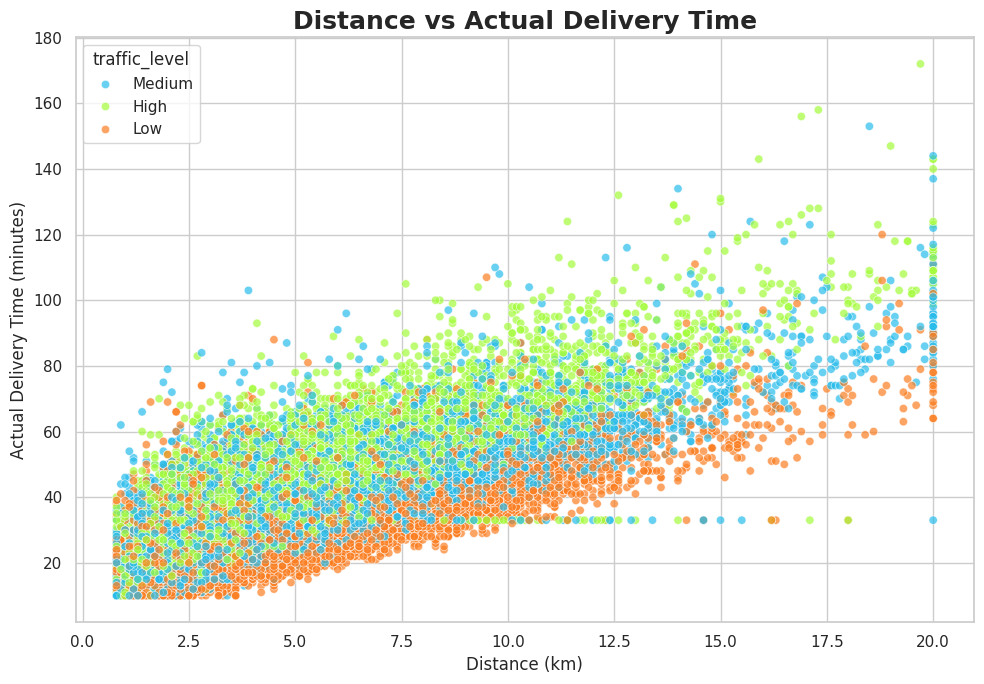

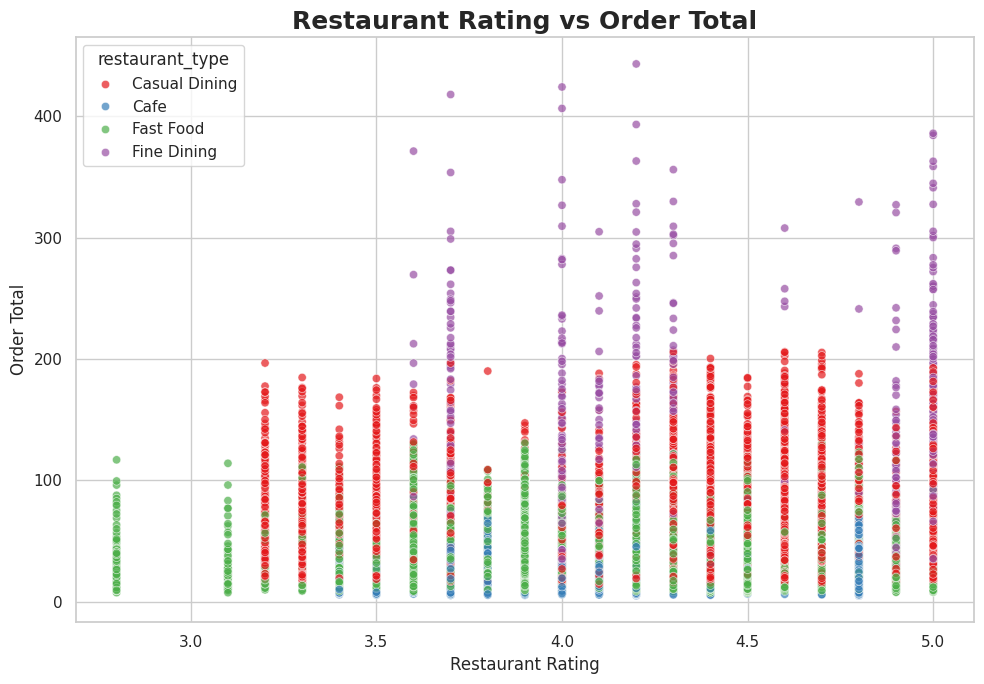

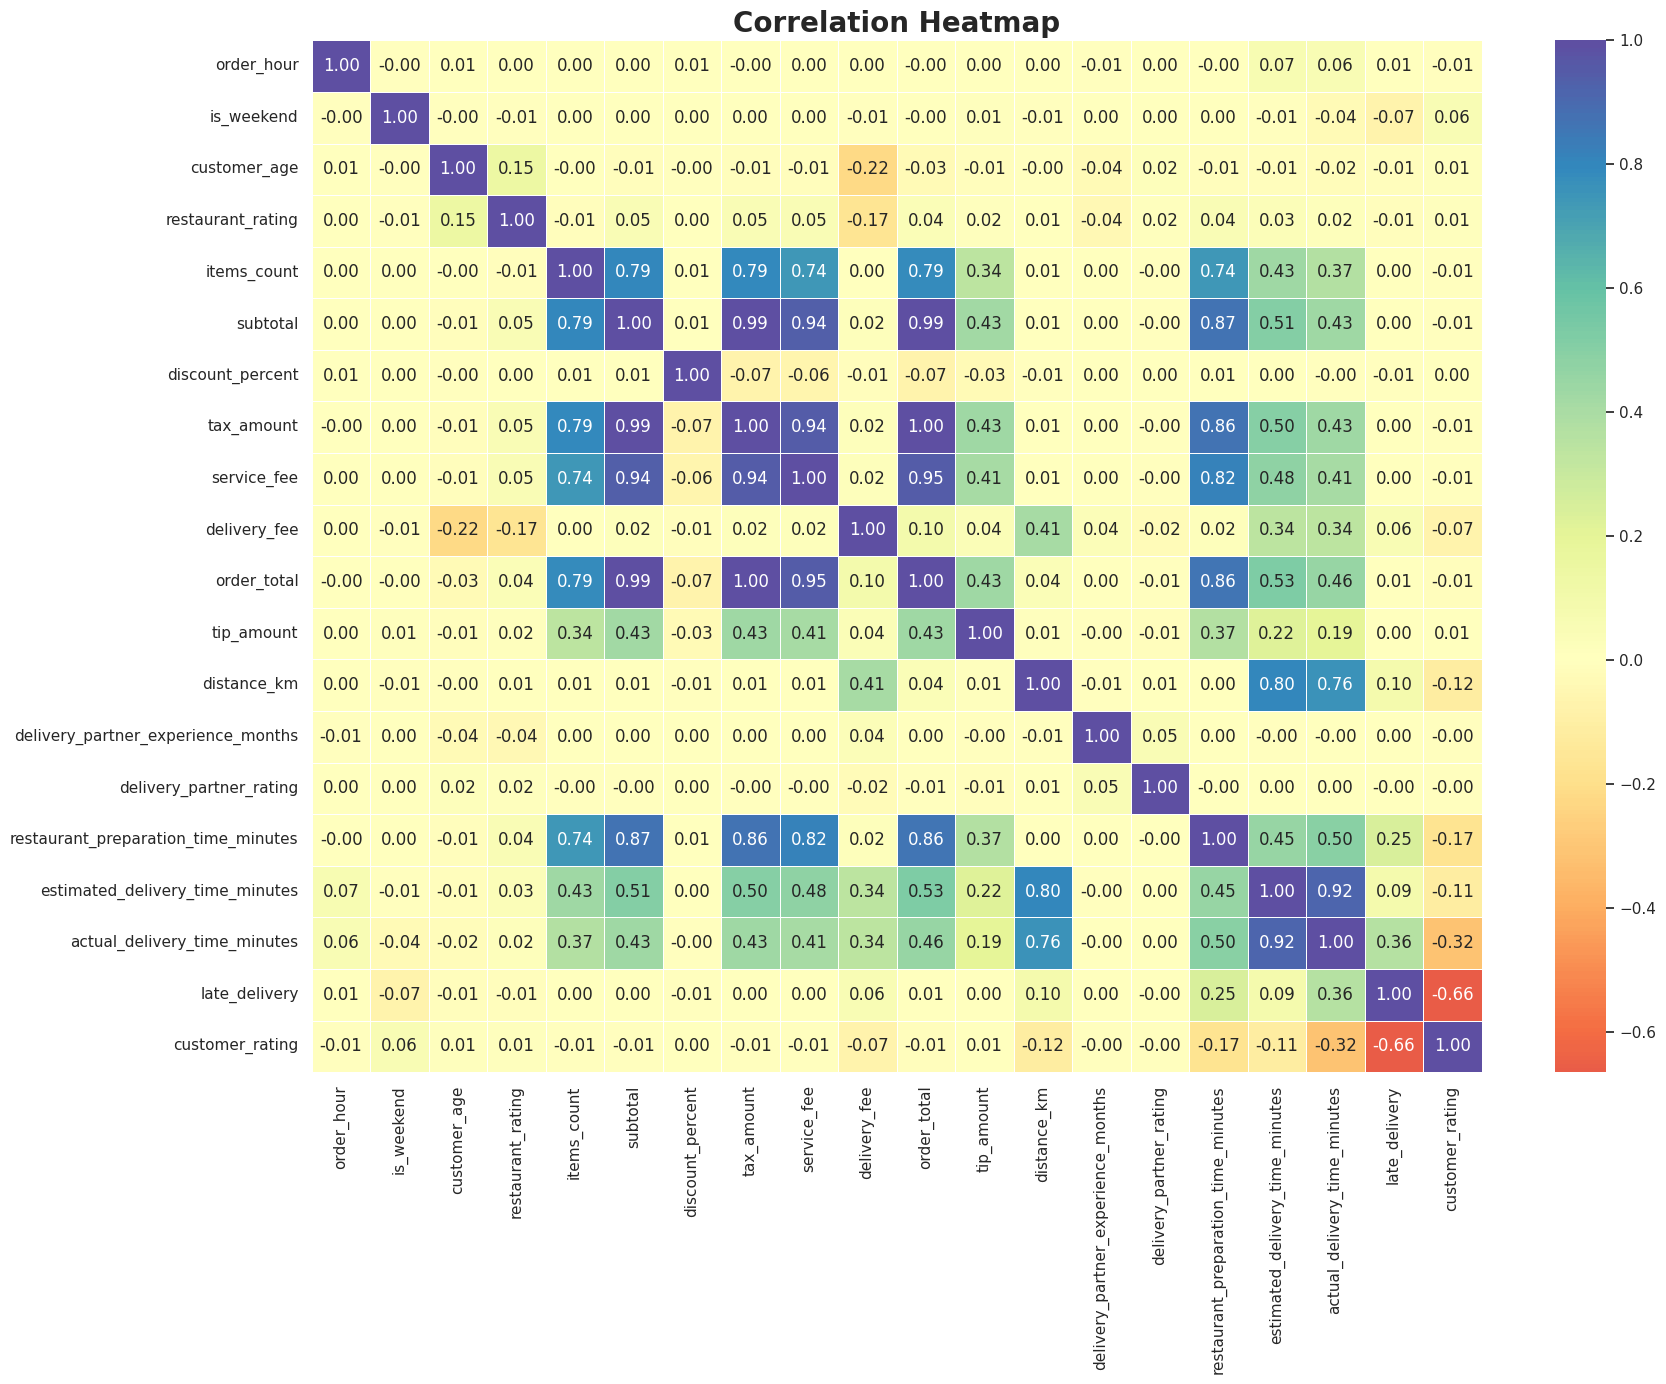

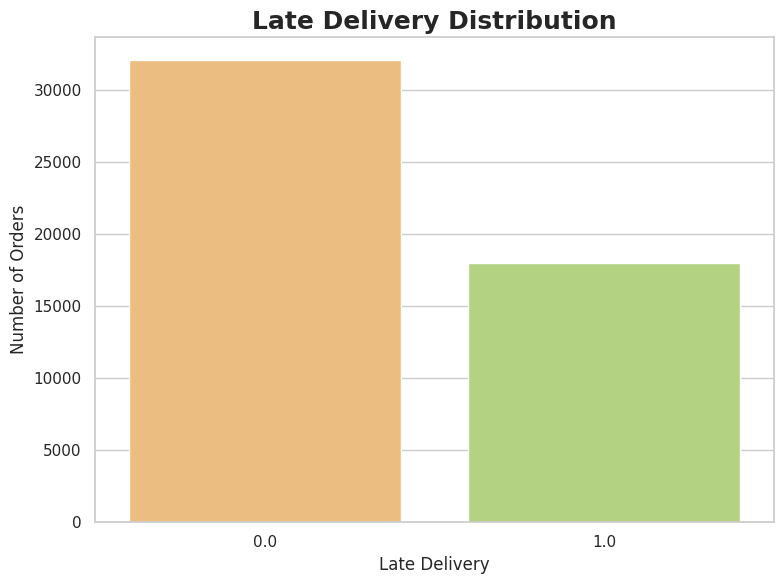

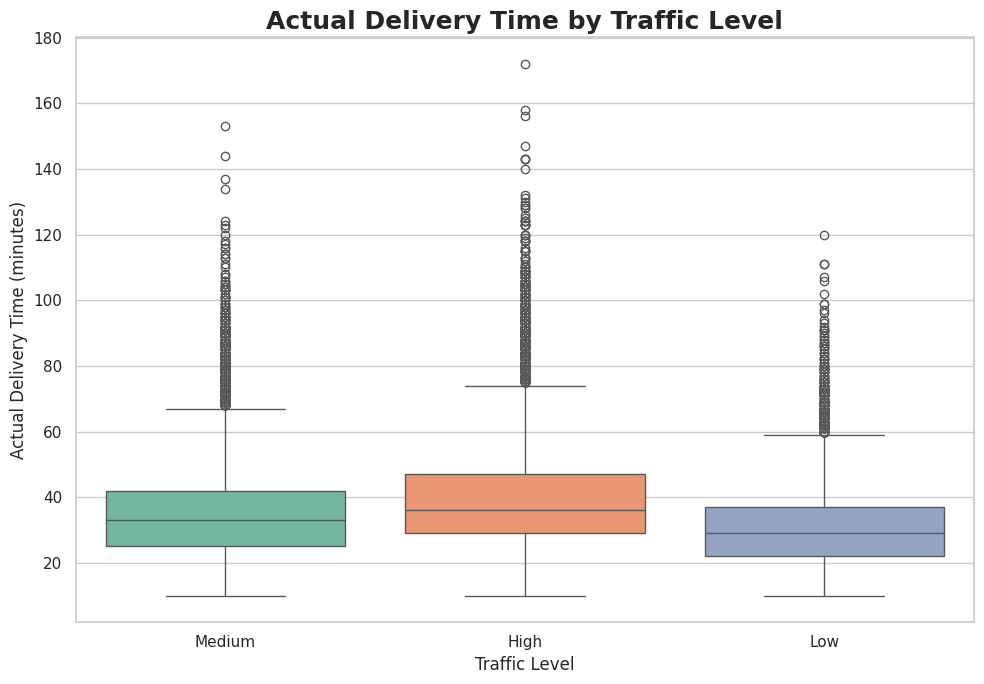

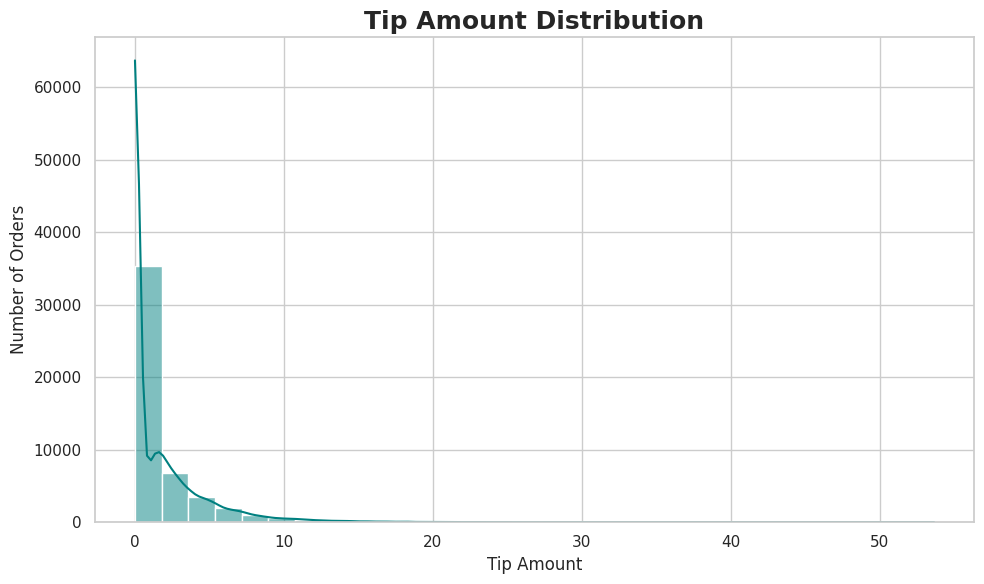


ALL VISUALIZATIONS COMPLETED SUCCESSFULLY


In [14]:
# ==========================================================
# FOOD DELIVERY DATASET - VISUALIZATION
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Use your cleaned dataframe
# ----------------------------------------------------------
data = df.copy()

# Seaborn style
sns.set_theme(style="whitegrid")

# ==========================================================
# 1. DATASET INFORMATION
# ==========================================================

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

# ==========================================================
# 2. NUMERICAL COLUMNS
# ==========================================================

numeric_cols = data.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical Columns:")
print(numeric_cols)

# ==========================================================
# 3. CATEGORICAL COLUMNS
# ==========================================================

categorical_cols = data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

# ==========================================================
# 4. HISTOGRAMS FOR NUMERICAL COLUMNS
# ==========================================================

data[numeric_cols].hist(
    figsize=(20, 18),
    bins=30,
    color="#4C72B0",
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ==========================================================
# 5. BOX PLOTS FOR NUMERICAL FEATURES
# ==========================================================

plt.figure(figsize=(20, 10))

sns.boxplot(
    data=data[numeric_cols],
    palette="husl"
)

plt.title(
    "Box Plot of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


# ==========================================================
# 6. ORDER STATUS DISTRIBUTION
# ==========================================================

if "order_status" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=data,
        x="order_status",
        hue="order_status",
        palette="Set2",
        legend=False
    )

    plt.title(
        "Order Status Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Order Status")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 7. PAYMENT METHOD DISTRIBUTION
# ==========================================================

if "payment_method" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=data,
        x="payment_method",
        hue="payment_method",
        palette="Set3",
        legend=False
    )

    plt.title(
        "Orders by Payment Method",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Payment Method")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 8. CITY DISTRIBUTION - TOP 15
# ==========================================================

if "city" in data.columns:

    city_counts = (
        data["city"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    city_counts.plot(
        kind="bar",
        color=plt.cm.tab20(
            np.linspace(
                0, 1,
                len(city_counts)
            )
        )
    )

    plt.title(
        "Top 15 Cities by Number of Orders",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("City")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 9. RESTAURANT CATEGORY DISTRIBUTION
# ==========================================================

if "restaurant_primary_category" in data.columns:

    category_counts = (
        data["restaurant_primary_category"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    category_counts.plot(
        kind="bar",
        color=plt.cm.rainbow(
            np.linspace(
                0, 1,
                len(category_counts)
            )
        )
    )

    plt.title(
        "Top Restaurant Categories",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Restaurant Category")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 10. WEATHER DISTRIBUTION
# ==========================================================

if "weather" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=data,
        x="weather",
        hue="weather",
        palette="Spectral",
        legend=False
    )

    plt.title(
        "Orders by Weather Condition",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Weather")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 11. TRAFFIC LEVEL DISTRIBUTION
# ==========================================================

if "traffic_level" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=data,
        x="traffic_level",
        hue="traffic_level",
        palette="coolwarm",
        legend=False
    )

    plt.title(
        "Orders by Traffic Level",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Traffic Level")
    plt.ylabel("Number of Orders")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 12. CUSTOMER TYPE DISTRIBUTION
# ==========================================================

if "customer_type" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=data,
        x="customer_type",
        hue="customer_type",
        palette="viridis",
        legend=False
    )

    plt.title(
        "Customer Type Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Customer Type")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 13. DELIVERY TIME DISTRIBUTION
# ==========================================================

if "actual_delivery_time_minutes" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data["actual_delivery_time_minutes"],
        bins=30,
        kde=True,
        color="purple"
    )

    plt.title(
        "Actual Delivery Time Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Actual Delivery Time (minutes)")
    plt.ylabel("Number of Orders")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 14. ORDER TOTAL DISTRIBUTION
# ==========================================================

if "order_total" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data["order_total"],
        bins=30,
        kde=True,
        color="orange"
    )

    plt.title(
        "Order Total Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Order Total")
    plt.ylabel("Number of Orders")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 15. DISTANCE VS DELIVERY TIME
# ==========================================================

if (
    "distance_km" in data.columns
    and
    "actual_delivery_time_minutes" in data.columns
):

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=data,
        x="distance_km",
        y="actual_delivery_time_minutes",
        hue="traffic_level"
        if "traffic_level" in data.columns
        else None,
        palette="turbo",
        alpha=0.7
    )

    plt.title(
        "Distance vs Actual Delivery Time",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Distance (km)")
    plt.ylabel("Actual Delivery Time (minutes)")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 16. RESTAURANT RATING VS ORDER TOTAL
# ==========================================================

if (
    "restaurant_rating" in data.columns
    and
    "order_total" in data.columns
):

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=data,
        x="restaurant_rating",
        y="order_total",
        hue="restaurant_type"
        if "restaurant_type" in data.columns
        else None,
        palette="Set1",
        alpha=0.7
    )

    plt.title(
        "Restaurant Rating vs Order Total",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Restaurant Rating")
    plt.ylabel("Order Total")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 17. CORRELATION HEATMAP
# ==========================================================

if len(numeric_cols) > 1:

    plt.figure(figsize=(18, 14))

    correlation = data[numeric_cols].corr()

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="Spectral",
        linewidths=0.5,
        center=0
    )

    plt.title(
        "Correlation Heatmap",
        fontsize=20,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ==========================================================
# 18. LATE DELIVERY DISTRIBUTION
# ==========================================================

if "late_delivery" in data.columns:

    plt.figure(figsize=(8, 6))

    sns.countplot(
        data=data,
        x="late_delivery",
        hue="late_delivery",
        palette="RdYlGn",
        legend=False
    )

    plt.title(
        "Late Delivery Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Late Delivery")
    plt.ylabel("Number of Orders")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 19. DELIVERY TIME BY TRAFFIC LEVEL
# ==========================================================

if (
    "traffic_level" in data.columns
    and
    "actual_delivery_time_minutes" in data.columns
):

    plt.figure(figsize=(10, 7))

    sns.boxplot(
        data=data,
        x="traffic_level",
        y="actual_delivery_time_minutes",
        hue="traffic_level",
        palette="Set2",
        legend=False
    )

    plt.title(
        "Actual Delivery Time by Traffic Level",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Traffic Level")
    plt.ylabel("Actual Delivery Time (minutes)")

    plt.tight_layout()
    plt.show()


# ==========================================================
# 20. TIP AMOUNT DISTRIBUTION
# ==========================================================

if "tip_amount" in data.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data["tip_amount"],
        bins=30,
        kde=True,
        color="teal"
    )

    plt.title(
        "Tip Amount Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Tip Amount")
    plt.ylabel("Number of Orders")

    plt.tight_layout()
    plt.show()


print("\n" + "=" * 70)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY")
print("=" * 70)

## Features Engieering

Original Shape: (50000, 37)

Regression Features:
['order_hour', 'day_of_week', 'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type', 'restaurant_type', 'restaurant_primary_category', 'restaurant_rating', 'items_count', 'subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee', 'order_total', 'payment_method', 'tip_amount', 'distance_km', 'weather', 'traffic_level', 'delivery_partner_experience_months', 'delivery_partner_rating', 'restaurant_preparation_time_minutes', 'estimated_delivery_time_minutes', 'order_status', 'cancellation_reason', 'order_day', 'order_dayofyear', 'order_week', 'order_value_per_item', 'discount_amount', 'total_extra_fees', 'distance_per_estimated_minute']

REGRESSION TRAIN TEST SPLIT
Training samples : 40000
Testing samples  : 10000

REGRESSION RESULTS
MAE  : 2.3563
RMSE : 2.9908
R²   : 0.9562


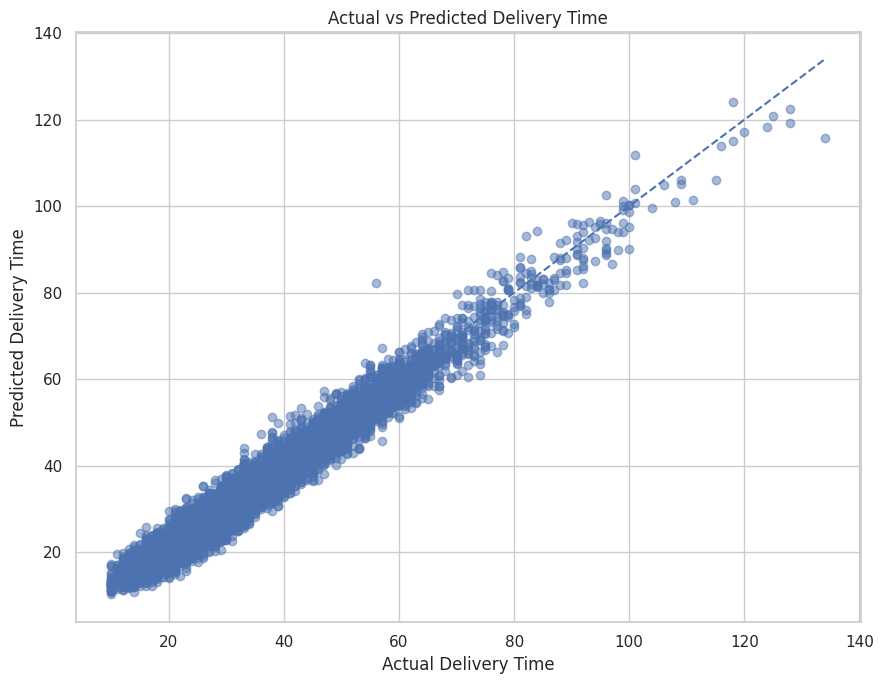


CLASSIFICATION TRAIN TEST SPLIT
Training samples : 40000
Testing samples  : 10000

Training class distribution:
late_delivery
0    25626
1    14374
Name: count, dtype: int64

CLASSIFICATION RESULTS
Accuracy: 81.03 %

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      6406
           1       0.78      0.66      0.71      3594

    accuracy                           0.81     10000
   macro avg       0.80      0.78      0.79     10000
weighted avg       0.81      0.81      0.81     10000



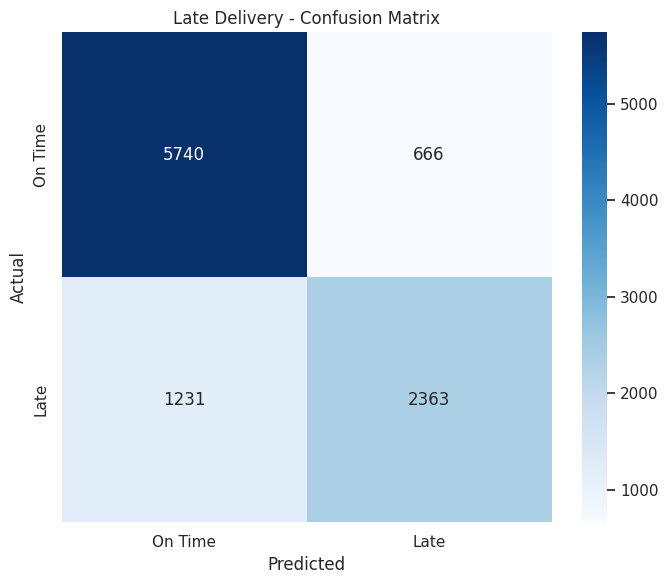


FINAL MODEL SUMMARY
Regression R²       : 0.9562
Regression MAE      : 2.3563
Regression RMSE     : 2.9908
Classification Accuracy : 81.03%


In [15]:
# ============================================================
# FOOD DELIVERY - FEATURE ENGINEERING + TRAIN/TEST
# REGRESSION + CLASSIFICATION + ACCURACY + R2
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. COPY DATA
# ============================================================

data = df.copy()

print("Original Shape:", data.shape)


# ============================================================
# 2. DATE/TIME FEATURE ENGINEERING
# ============================================================

# Convert date safely
if "order_timestamp" in data.columns:

    data["order_timestamp"] = pd.to_datetime(
        data["order_timestamp"],
        errors="coerce"
    )

    data["order_year"] = (
        data["order_timestamp"].dt.year
    )

    data["order_month"] = (
        data["order_timestamp"].dt.month
    )

    data["order_day"] = (
        data["order_timestamp"].dt.day
    )

    data["order_dayofyear"] = (
        data["order_timestamp"].dt.dayofyear
    )

    data["order_week"] = (
        data["order_timestamp"].dt.isocalendar()
        .week
        .astype(float)
    )


# ============================================================
# 3. NUMERICAL FEATURE ENGINEERING
# ============================================================

# Delivery time difference
if (
    "estimated_delivery_time_minutes" in data.columns
    and
    "actual_delivery_time_minutes" in data.columns
):

    data["delivery_time_difference"] = (
        data["actual_delivery_time_minutes"]
        - data["estimated_delivery_time_minutes"]
    )


# Order value per item
if (
    "order_total" in data.columns
    and
    "items_count" in data.columns
):

    data["order_value_per_item"] = (
        data["order_total"]
        /
        data["items_count"].replace(0, np.nan)
    )


# Discount amount
if (
    "subtotal" in data.columns
    and
    "discount_percent" in data.columns
):

    data["discount_amount"] = (
        data["subtotal"]
        * data["discount_percent"]
        / 100
    )


# Total additional charges
fee_columns = [
    "tax_amount",
    "service_fee",
    "delivery_fee"
]

existing_fee_columns = [
    col for col in fee_columns
    if col in data.columns
]

if existing_fee_columns:

    data["total_extra_fees"] = (
        data[existing_fee_columns]
        .sum(axis=1)
    )


# Distance per estimated minute
if (
    "distance_km" in data.columns
    and
    "estimated_delivery_time_minutes" in data.columns
):

    data["distance_per_estimated_minute"] = (
        data["distance_km"]
        /
        data["estimated_delivery_time_minutes"]
        .replace(0, np.nan)
    )


# ============================================================
# 4. REMOVE TARGET-LEAKING FEATURES
# ============================================================

# For regression, actual delivery time must NOT be used
# as an input feature.

# delivery_time_difference also contains actual delivery time,
# so it must not be used as a predictor.

leakage_columns = [
    "actual_delivery_time_minutes",
    "delivery_time_difference",
    "late_delivery",
    "customer_rating"
]

# We remove customer_rating because it may be given AFTER
# the delivery and therefore can leak future information.

data = data.drop(
    columns=[
        col for col in leakage_columns
        if col in data.columns
    ],
    errors="ignore"
)


# ============================================================
# 5. REMOVE IDENTIFIER COLUMNS
# ============================================================

identifier_columns = [
    "order_id",
    "customer_id",
    "restaurant_id",
    "driver_id",
    "order_date",
    "order_timestamp"
]

data = data.drop(
    columns=[
        col for col in identifier_columns
        if col in data.columns
    ],
    errors="ignore"
)


# ============================================================
# 6. CLEAN INFINITE VALUES
# ============================================================

data.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# ============================================================
# 7. REGRESSION DATA
# ============================================================

# Target
reg_target = "actual_delivery_time_minutes"

# Retrieve target from original df
y_reg = df[reg_target].copy()

# Make sure target is numeric
y_reg = pd.to_numeric(
    y_reg,
    errors="coerce"
)

# Keep only rows where target exists
valid_reg = y_reg.notna()

X_reg = data.loc[
    valid_reg
].copy()

y_reg = y_reg.loc[
    valid_reg
].copy()


# ============================================================
# 8. REMOVE CONSTANT COLUMNS
# ============================================================

constant_columns = [
    col for col in X_reg.columns
    if X_reg[col].nunique(dropna=False) <= 1
]

X_reg = X_reg.drop(
    columns=constant_columns
)

print("\nRegression Features:")
print(X_reg.columns.tolist())


# ============================================================
# 9. IDENTIFY COLUMN TYPES
# ============================================================

numeric_features_reg = X_reg.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_reg = X_reg.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ============================================================
# 10. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features_reg
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features_reg
        )
    ]
)


# ============================================================
# 11. TRAIN TEST SPLIT - REGRESSION
# ============================================================

X_train_reg, X_test_reg, y_train_reg, y_test_reg = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)

print("\n" + "=" * 70)
print("REGRESSION TRAIN TEST SPLIT")
print("=" * 70)

print("Training samples :", X_train_reg.shape[0])
print("Testing samples  :", X_test_reg.shape[0])


# ============================================================
# 12. RANDOM FOREST REGRESSION
# ============================================================

regression_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor_reg
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=150,
                random_state=42,
                n_jobs=-1,
                max_depth=20
            )
        )
    ]
)


# ============================================================
# 13. TRAIN REGRESSION MODEL
# ============================================================

regression_model.fit(
    X_train_reg,
    y_train_reg
)


# ============================================================
# 14. REGRESSION PREDICTION
# ============================================================

y_pred_reg = regression_model.predict(
    X_test_reg
)


# ============================================================
# 15. REGRESSION METRICS
# ============================================================

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("\n" + "=" * 70)
print("REGRESSION RESULTS")
print("=" * 70)

print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))
print("R²   :", round(r2, 4))


# ============================================================
# 16. REGRESSION ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

minimum = min(
    y_test_reg.min(),
    y_pred_reg.min()
)

maximum = max(
    y_test_reg.max(),
    y_pred_reg.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Delivery Time"
)

plt.ylabel(
    "Predicted Delivery Time"
)

plt.title(
    "Actual vs Predicted Delivery Time"
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. CLASSIFICATION DATA
# ============================================================

classification_target = "late_delivery"

y_class = df[
    classification_target
].copy()


# Convert classification target if necessary
if y_class.dtype == "object":

    y_class = (
        y_class
        .astype(str)
        .str.lower()
        .str.strip()
        .map({
            "yes": 1,
            "no": 0,
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0
        })
    )

else:

    y_class = pd.to_numeric(
        y_class,
        errors="coerce"
    )


# ============================================================
# 18. CLASSIFICATION FEATURES
# ============================================================

# Use the same engineered features,
# but do NOT use late_delivery itself.

X_class = data.copy()

valid_class = y_class.notna()

X_class = X_class.loc[
    valid_class
]

y_class = y_class.loc[
    valid_class
].astype(int)


# Remove constant columns
constant_class_columns = [
    col for col in X_class.columns
    if X_class[col].nunique(dropna=False) <= 1
]

X_class = X_class.drop(
    columns=constant_class_columns
)


# ============================================================
# 19. COLUMN TYPES FOR CLASSIFICATION
# ============================================================

numeric_features_class = X_class.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_class = X_class.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ============================================================
# 20. CLASSIFICATION PREPROCESSOR
# ============================================================

preprocessor_class = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features_class
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features_class
        )
    ]
)


# ============================================================
# 21. TRAIN TEST SPLIT - CLASSIFICATION
# ============================================================

X_train_class, X_test_class, y_train_class, y_test_class = (
    train_test_split(
        X_class,
        y_class,
        test_size=0.20,
        random_state=42,
        stratify=y_class
    )
)

print("\n" + "=" * 70)
print("CLASSIFICATION TRAIN TEST SPLIT")
print("=" * 70)

print("Training samples :", X_train_class.shape[0])
print("Testing samples  :", X_test_class.shape[0])

print("\nTraining class distribution:")
print(y_train_class.value_counts())


# ============================================================
# 22. RANDOM FOREST CLASSIFIER
# ============================================================

classification_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor_class
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=150,
                random_state=42,
                n_jobs=-1,
                max_depth=20,
                class_weight="balanced"
            )
        )
    ]
)


# ============================================================
# 23. TRAIN CLASSIFICATION MODEL
# ============================================================

classification_model.fit(
    X_train_class,
    y_train_class
)


# ============================================================
# 24. CLASSIFICATION PREDICTION
# ============================================================

y_pred_class = classification_model.predict(
    X_test_class
)


# ============================================================
# 25. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

print("\n" + "=" * 70)
print("CLASSIFICATION RESULTS")
print("=" * 70)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ============================================================
# 26. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_class,
        zero_division=0
    )
)


# ============================================================
# 27. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_class,
    y_pred_class
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time", "Late"],
    yticklabels=["On Time", "Late"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Late Delivery - Confusion Matrix"
)

plt.tight_layout()
plt.show()


# ============================================================
# 28. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(
    f"Regression R²       : {r2:.4f}"
)

print(
    f"Regression MAE      : {mae:.4f}"
)

print(
    f"Regression RMSE     : {rmse:.4f}"
)

print(
    f"Classification Accuracy : {accuracy * 100:.2f}%"
)

## Thanks........Please Upvote